2025-08-13 14:04:17.395611: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-13 14:04:17.408209: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-13 14:04:17.423016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755086657.448365   95027 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755086657.455767   95027 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755086657.479669   95027 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Class weights: {np.int64(0): np.float64(1.0)}
2/2 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - categorical_accuracy: 1.0000 - loss: 1.3032 - val_categorical_accuracy: 1.0000 - val_loss: 1.2991


Model: "SeqLengthMLP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mppc_length_input   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_length_input  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input (Concatenate) │ (None, 2)         │          0 │ mppc_length_inpu… │
│                     │                   │            │ pixel_length_inp… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder (MLP)       │ (None, 10)        │         89 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (MLP)       │ (None, 4)         │        141 │ encoder[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 230 (920.00 B)

 Trainable params: 230 (920.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - categorical_accuracy: 0.0000e+00 - loss: 58.9782 - val_categorical_accuracy: 0.0000e+00 - val_loss: 24.2999
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


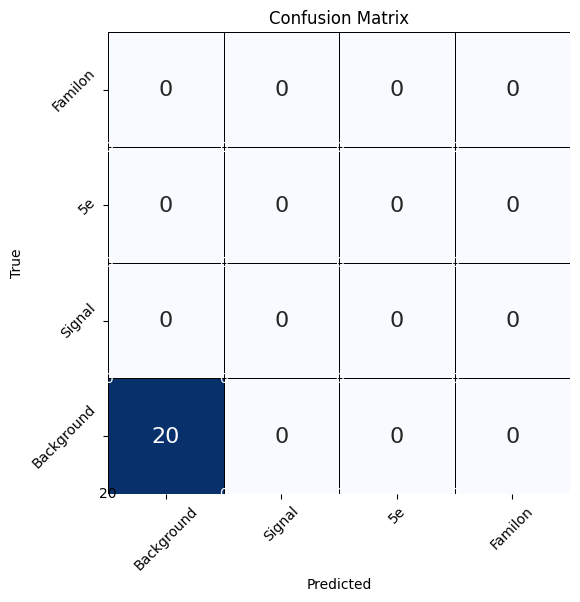

In [ ]:
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn as sk
import sys
import seaborn as sns

sys.path.append("../")
ROOT_DIR = "/afs/desy.de/user/a/aulich/mu3e_trigger"
DATA_DIR = f"{ROOT_DIR}/mu3e_trigger_data"
PLOTS_DIR = f"{ROOT_DIR}/plots"
MODEL_DIR = f"{ROOT_DIR}/models"


SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_mppc_spacetime.npy"
E5_PIXEL_FILE = f"{DATA_DIR}/5e_pixel_spacetime.npy"
E5_MPPC_FILE = f"{DATA_DIR}/5e_mppc_spacetime.npy"
FAMILON_PIXEL_FILE = f"{DATA_DIR}/familon_pixel_spacetime.npy"
FAMILON_MPPC_FILE = f"{DATA_DIR}/familon_mppc_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_pixel_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_mppc_spacetime.npy"

bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)
e5_pixel_spacetime = np.load(E5_PIXEL_FILE)
e5_mppc_spacetime = np.load(E5_MPPC_FILE)
familon_pixel_spacetime = np.load(FAMILON_PIXEL_FILE)
familon_mppc_spacetime = np.load(FAMILON_MPPC_FILE)

num_classes = 4

class_names = [
    "Background",
    "Signal",
    "5e",
    "Familon",
]

def make_multi_class_dataset(data_list : list[tuple]):
    X_pixel = np.concatenate([data[0] for data in data_list], axis=0)
    X_mppc = np.concatenate([data[1] for data in data_list], axis=0)
    y = np.concatenate(
        [np.full(len(data[0]), i) for i, data in enumerate(data_list)], axis=0
    )
    y = keras.utils.to_categorical(y, num_classes=num_classes)
    return X_pixel, X_mppc, y



X_pixel, X_mppc, y = make_multi_class_dataset(
    [
        (bg_pixel_spacetime, bg_mppc_spacetime),
        (sig_only_pixel_spacetime, sig_only_mppc_spacetime),
        (e5_pixel_spacetime, e5_mppc_spacetime),
        (familon_pixel_spacetime, familon_mppc_spacetime),
    ]
)



input_seq_len = sig_only_pixel_spacetime.shape[1]
input_dim = sig_only_pixel_spacetime.shape[2]

pixel_input = keras.Input(shape=(input_seq_len, input_dim), name="pixel_input")
mppc_input = keras.Input(shape=(input_seq_len, input_dim), name="mppc_input")


from src.model.components import (
    SelfAttentionStack,
    SelfAttentionBlock,
    CrossAttentionBlock,
    PoolingAttentionBlock,
    GenerateMask,
    MLP,
)

feature_dim = 8
num_heads = 6
dropout_rate = 0

pixel_mask = GenerateMask(name="mask")(pixel_input)
pixel_embedding = MLP(
    num_layers=4,
    output_dim=feature_dim,
    activation="relu",
    name="pixel_embedding",
    dropout_rate=dropout_rate,
)(pixel_input)

pixel_self_attention = SelfAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size = 3,
    name="pixel_self_attention",
    dropout_rate=dropout_rate,
    pre_ln=True,
)(pixel_embedding , mask = pixel_mask)
mppc_mask = GenerateMask(name="mppc_mask")(mppc_input)
mppc_embedding = MLP(
    num_layers=4,
    output_dim=feature_dim,
    activation="relu",
    name="mppc_embedding",
    dropout_rate=dropout_rate,
)(mppc_input)
mppc_self_attention = SelfAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size = 3,
    name="mppc_self_attention",
    dropout_rate=dropout_rate,
    pre_ln=True,
)(mppc_embedding , mask = mppc_mask)


pixel_attend_mppc, mppc_attend_pixel = CrossAttentionBlock(
    num_heads=num_heads,
    key_dim=feature_dim,
    name="cross_attention",
    dropout_rate=dropout_rate,
    pre_ln=True,
)([pixel_self_attention, mppc_self_attention])


pixel_pooling = PoolingAttentionBlock(
    num_seeds = 1,
    key_dim=feature_dim,
    name="pooling_attention",
    dropout_rate=dropout_rate,
)(pixel_attend_mppc, mask=pixel_mask)

mppc_pooling = PoolingAttentionBlock(
    num_seeds = 1,
    key_dim=feature_dim,
    name="mppc_pooling_attention",
    dropout_rate=dropout_rate,
)(mppc_attend_pixel, mask=mppc_mask)


latent_space = keras.layers.Concatenate(name="latent_space")([pixel_pooling, mppc_pooling])
latent_space = keras.layers.Flatten(name="flatten")(latent_space)
output = MLP(
    num_layers=4,
    output_dim=num_classes,
    activation="softmax",
    name="output",
    dropout_rate=dropout_rate,
)(latent_space)

model = keras.Model(
    inputs=[pixel_input, mppc_input],
    outputs=output,
    name="ClassificationModel",
)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5, global_clipnorm=1.0),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()],)


from sklearn.model_selection import train_test_split

(
    X_pixel_train,
    X_pixel_test,
    X_mppc_train,
    X_mppc_test,
    y_train,
    y_test,
) = train_test_split(
    X_pixel,
    X_mppc,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

class_weights = {
    label: 1/np.mean(y_train.argmax(axis = 1) == label) for label in np.unique(y_train.argmax(axis=1))
}

print("Class weights:", class_weights)

model.fit(
    x=[X_pixel_train, X_mppc_train],
    y=y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
    class_weight=class_weights,
)

keras.Model.save(model, f"{MODEL_DIR}/transformer_embedding.keras")

hahatest_seq_length = (X_pixel_test != -1).all(axis=-1).sum(axis=-1) + (
    X_mppc_test != -1
).all(axis=-1).sum(axis=-1)
test_mppc_length = (X_mppc_test != -1).all(axis=-1).sum(axis=-1)
test_pixel_length = (X_pixel_test != -1).all(axis=-1).sum(axis=-1)
train_mppc_length = (X_mppc_train != -1).all(axis=-1).sum(axis=-1)
train_pixel_length = (X_pixel_train != -1).all(axis=-1).sum(axis=-1)


mppc_lenght_input = keras.Input(shape=(1,), name="mppc_length_input")
pixel_length_input = keras.Input(shape=(1,), name="pixel_length_input")

input = keras.layers.Concatenate(name="input")(
    [
        mppc_lenght_input,
        pixel_length_input,
    ]
)
encoder = MLP(
    num_layers=3,
    output_dim=10,
    name="encoder",
    activation="relu",
)(input)
decoder = MLP(
    num_layers=3,
    output_dim=num_classes,
    name="decoder",
    activation="softmax",
)(encoder)
seq_length_mlp = keras.Model(
    inputs=[mppc_lenght_input, pixel_length_input],
    outputs=decoder,
    name="SeqLengthMLP",
)

seq_length_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()],
)
seq_length_mlp.summary()


seq_length_mlp.fit(
    x=[train_mppc_length, train_pixel_length],
    y=y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
    class_weight={
        label: np.sum(y_train == label) / len(y_train)
        for label in np.unique(y_train)
        if label in [0, 1]
    },
)


test_predictions = model.predict([X_pixel_test, X_mppc_test])
test_seq_length = seq_length_mlp.predict([test_mppc_length, test_pixel_length])

from sklearn.metrics import confusion_matrix, roc_curve, auc

confusion_matrix_result = confusion_matrix(y_test.argmax(axis=1), test_predictions.argmax(axis=1),labels=np.arange(num_classes))
normed_confusion_matrix = confusion_matrix_result.astype("float") / (confusion_matrix_result.sum(axis=1)[:, np.newaxis] + 1e-6)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    normed_confusion_matrix,
    annot=True,
    cmap="Blues",
    cbar=False,
    ax=ax,
    square=True,
    linewidths=0.5,
    linecolor="black",
    annot_kws={"size": 16},
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
ax.set_xticks(np.arange(num_classes) + 0.5)
ax.set_yticks(np.arange(num_classes) + 0.5)
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlim(0, num_classes)
ax.set_ylim(0, num_classes)
ax.xaxis.set_ticks_position("bottom")
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=45)
fig.savefig(f"{PLOTS_DIR}/confusion_matrix.png")